In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "dplyr", "readr", "tibble", "stringr", "tidyr", "ggplot2")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))
rstan_options(auto_write = TRUE)

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”

Attaching package: ‘tidyr’


The following object is masked from ‘package:rstan’:

    extract


Warning message:
“package ‘ggplot

In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative"))
  )

In [4]:
model_tbl_m1 <- model_tbl %>%
  dplyr::filter(
    !is.na(confinan_ord), !is.na(polviews), !is.na(age_std), !is.na(income_std),
    !is.na(degree), !is.na(sex), !is.na(region)
  )

X_m1 <- stats::model.matrix(~ polviews + age_std + income_std + degree + sex + region, data = model_tbl_m1)
X_m1 <- X_m1[, colnames(X_m1) != "(Intercept)", drop = FALSE]
y_m1 <- as.integer(model_tbl_m1$confinan_ord)

stan_data_m1 <- list(
  N = nrow(X_m1),
  K = ncol(X_m1),
  y = y_m1,
  X = X_m1
)

tibble::tibble(metric = c("m1_N", "m1_K"), value = c(stan_data_m1$N, stan_data_m1$K))

metric,value
<chr>,<int>
m1_N,2223
m1_K,11


In [5]:
model_tbl_m2 <- model_tbl %>%
  dplyr::filter(
    !is.na(confinan_ord), !is.na(polviews_bin), !is.na(age_std), !is.na(income_std),
    !is.na(degree), !is.na(sex), !is.na(region)
  )

X_m2 <- stats::model.matrix(~ age_std + income_std + degree + sex + region, data = model_tbl_m2)
X_m2 <- X_m2[, colnames(X_m2) != "(Intercept)", drop = FALSE]
y_m2 <- as.integer(model_tbl_m2$confinan_ord)
ideology_levels <- levels(model_tbl_m2$polviews_bin)
ideology_id <- as.integer(model_tbl_m2$polviews_bin)

stan_data_m2 <- list(
  N = nrow(X_m2),
  K = ncol(X_m2),
  G = length(ideology_levels),
  y = y_m2,
  X = X_m2,
  ideology_id = ideology_id
)

tibble::tibble(metric = c("m2_N", "m2_K", "m2_G"), value = c(stan_data_m2$N, stan_data_m2$K, stan_data_m2$G))

metric,value
<chr>,<int>
m2_N,2223
m2_K,10
m2_G,3


In [6]:
sm_m1 <- rstan::stan_model(file = "../stan/model1_pooled_ordinal.stan", model_name = "model1_pooled_ordinal")
sm_m2 <- rstan::stan_model(file = "../stan/model2_hierarchical_ordinal.stan", model_name = "model2_hierarchical_ordinal")

recompiling to avoid crashing R session

recompiling to avoid crashing R session



In [7]:
fit_m1_vi <- rstan::vb(
  object = sm_m1,
  data = stan_data_m1,
  algorithm = "meanfield",
  output_samples = 4000,
  seed = 405,
  tol_rel_obj = 0.001,
  eval_elbo = 100,
  iter = 20000
)

lp_m1 <- rstan::extract(fit_m1_vi, pars = "lp__", permuted = TRUE)$lp__
length(lp_m1)

Chain 1: ------------------------------------------------------------
Chain 1: EXPERIMENTAL ALGORITHM:
Chain 1:   This procedure has not been thoroughly tested and may be unstable
Chain 1:   or buggy. The interface is subject to change.
Chain 1: ------------------------------------------------------------
Chain 1: 
Chain 1: 
Chain 1: 
Chain 1: Gradient evaluation took 0.000175 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 1.75 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Begin eta adaptation.
Chain 1: Iteration:   1 / 250 [  0%]  (Adaptation)
Chain 1: Iteration:  50 / 250 [ 20%]  (Adaptation)
Chain 1: Iteration: 100 / 250 [ 40%]  (Adaptation)
Chain 1: Iteration: 150 / 250 [ 60%]  (Adaptation)
Chain 1: Iteration: 200 / 250 [ 80%]  (Adaptation)
Chain 1: Success! Found best value [eta = 1] earlier than expected.
Chain 1: 
Chain 1: Begin stochastic gradient ascent.
Chain 1:   iter             ELBO   delta_ELBO_me

Warning message:
“Pareto k diagnostic value is 1.02. Resampling is disabled. Decreasing tol_rel_obj may help if variational algorithm has terminated prematurely. Otherwise consider using sampling instead.”


[1] 4000

In [8]:
fit_m2_vi <- rstan::vb(
  object = sm_m2,
  data = stan_data_m2,
  algorithm = "meanfield",
  output_samples = 4000,
  seed = 406,
  tol_rel_obj = 0.001,
  eval_elbo = 100,
  iter = 20000
)

lp_m2 <- rstan::extract(fit_m2_vi, pars = "lp__", permuted = TRUE)$lp__
length(lp_m2)

Chain 1: ------------------------------------------------------------
Chain 1: EXPERIMENTAL ALGORITHM:
Chain 1:   This procedure has not been thoroughly tested and may be unstable
Chain 1:   or buggy. The interface is subject to change.
Chain 1: ------------------------------------------------------------
Chain 1: 
Chain 1: 
Chain 1: 
Chain 1: Gradient evaluation took 0.001197 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 11.97 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Begin eta adaptation.
Chain 1: Iteration:   1 / 250 [  0%]  (Adaptation)
Chain 1: Iteration:  50 / 250 [ 20%]  (Adaptation)
Chain 1: Iteration: 100 / 250 [ 40%]  (Adaptation)
Chain 1: Iteration: 150 / 250 [ 60%]  (Adaptation)
Chain 1: Iteration: 200 / 250 [ 80%]  (Adaptation)
Chain 1: Success! Found best value [eta = 1] earlier than expected.
Chain 1: 
Chain 1: Begin stochastic gradient ascent.
Chain 1:   iter             ELBO   delta_ELBO_m

Warning message:
“Pareto k diagnostic value is 1.06. Resampling is disabled. Decreasing tol_rel_obj may help if variational algorithm has terminated prematurely. Otherwise consider using sampling instead.”


[1] 4000

In [9]:
summarize_fit <- function(fit_obj) {
  out <- as.data.frame(rstan::summary(fit_obj)$summary, check.names = FALSE)
  out$parameter <- rownames(out)
  out %>% dplyr::relocate(parameter)
}

m1_vi_summary <- summarize_fit(fit_m1_vi)
m2_vi_summary <- summarize_fit(fit_m2_vi)

m1_vi_key <- m1_vi_summary %>%
  dplyr::filter(stringr::str_detect(parameter, "^beta\\[|^c\\[")) %>%
  dplyr::select(parameter, mean_vi = mean, sd_vi = sd, q025_vi = `2.5%`, q50_vi = `50%`, q975_vi = `97.5%`)

m2_vi_key <- m2_vi_summary %>%
  dplyr::filter(stringr::str_detect(parameter, "^beta\\[|^c\\[|^mu_alpha$|^sigma_alpha$|^alpha\\[")) %>%
  dplyr::select(parameter, mean_vi = mean, sd_vi = sd, q025_vi = `2.5%`, q50_vi = `50%`, q975_vi = `97.5%`)

list(nrow(m1_vi_key), nrow(m2_vi_key))

[[1]]
[1] 13

[[2]]
[1] 17

In [10]:
m1_nuts_summary <- readr::read_csv("../output/model1_nuts/fit_summary.csv", show_col_types = FALSE) %>%
  dplyr::filter(stringr::str_detect(parameter, "^beta\\[|^c\\[")) %>%
  dplyr::select(parameter, mean_nuts = mean, sd_nuts = sd, q025_nuts = `2.5%`, q50_nuts = `50%`, q975_nuts = `97.5%`)

m2_nuts_summary <- readr::read_csv("../output/model2_nuts/fit_summary.csv", show_col_types = FALSE) %>%
  dplyr::filter(stringr::str_detect(parameter, "^beta\\[|^c\\[|^mu_alpha$|^sigma_alpha$|^alpha\\[")) %>%
  dplyr::select(parameter, mean_nuts = mean, sd_nuts = sd, q025_nuts = `2.5%`, q50_nuts = `50%`, q975_nuts = `97.5%`)

m1_compare <- m1_nuts_summary %>%
  dplyr::inner_join(m1_vi_key, by = "parameter") %>%
  dplyr::mutate(
    abs_mean_diff = abs(mean_nuts - mean_vi),
    sd_ratio_vi_to_nuts = sd_vi / sd_nuts
  ) %>%
  dplyr::arrange(dplyr::desc(abs_mean_diff))

m2_compare <- m2_nuts_summary %>%
  dplyr::inner_join(m2_vi_key, by = "parameter") %>%
  dplyr::mutate(
    abs_mean_diff = abs(mean_nuts - mean_vi),
    sd_ratio_vi_to_nuts = sd_vi / sd_nuts
  ) %>%
  dplyr::arrange(dplyr::desc(abs_mean_diff))

list(nrow(m1_compare), nrow(m2_compare))

[[1]]
[1] 13

[[2]]
[1] 17

In [11]:
compare_metrics <- tibble::tibble(
  model = c("Model1", "Model2"),
  n_parameters = c(nrow(m1_compare), nrow(m2_compare)),
  median_abs_mean_diff = c(stats::median(m1_compare$abs_mean_diff), stats::median(m2_compare$abs_mean_diff)),
  median_sd_ratio_vi_to_nuts = c(stats::median(m1_compare$sd_ratio_vi_to_nuts), stats::median(m2_compare$sd_ratio_vi_to_nuts)),
  p10_sd_ratio_vi_to_nuts = c(stats::quantile(m1_compare$sd_ratio_vi_to_nuts, 0.10), stats::quantile(m2_compare$sd_ratio_vi_to_nuts, 0.10)),
  p90_sd_ratio_vi_to_nuts = c(stats::quantile(m1_compare$sd_ratio_vi_to_nuts, 0.90), stats::quantile(m2_compare$sd_ratio_vi_to_nuts, 0.90))
)
compare_metrics

model,n_parameters,median_abs_mean_diff,median_sd_ratio_vi_to_nuts,p10_sd_ratio_vi_to_nuts,p90_sd_ratio_vi_to_nuts
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Model1,13,0.008539536,0.6648920,0.31350795,0.9379152
Model2,17,0.036147343,0.5723045,0.07070987,0.8530557


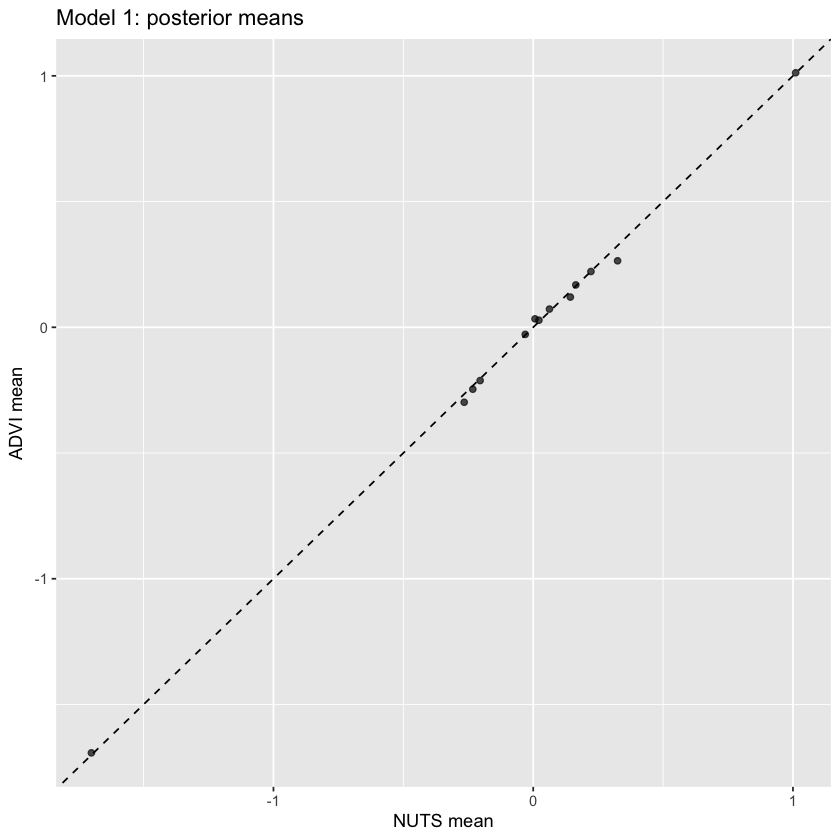

In [12]:
p_m1_mean <- ggplot2::ggplot(m1_compare, ggplot2::aes(x = mean_nuts, y = mean_vi)) +
  ggplot2::geom_point(alpha = 0.7) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggplot2::labs(x = "NUTS mean", y = "ADVI mean", title = "Model 1: posterior means")

p_m2_mean <- ggplot2::ggplot(m2_compare, ggplot2::aes(x = mean_nuts, y = mean_vi)) +
  ggplot2::geom_point(alpha = 0.7) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggplot2::labs(x = "NUTS mean", y = "ADVI mean", title = "Model 2: posterior means")

p_m1_sd <- ggplot2::ggplot(m1_compare, ggplot2::aes(x = sd_nuts, y = sd_vi)) +
  ggplot2::geom_point(alpha = 0.7) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggplot2::labs(x = "NUTS sd", y = "ADVI sd", title = "Model 1: posterior sd")

p_m2_sd <- ggplot2::ggplot(m2_compare, ggplot2::aes(x = sd_nuts, y = sd_vi)) +
  ggplot2::geom_point(alpha = 0.7) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggplot2::labs(x = "NUTS sd", y = "ADVI sd", title = "Model 2: posterior sd")

p_m2_alpha <- ggplot2::ggplot(m2_compare %>% dplyr::filter(stringr::str_detect(parameter, "^alpha\\[")), ggplot2::aes(x = parameter, y = sd_ratio_vi_to_nuts)) +
  ggplot2::geom_col() +
  ggplot2::geom_hline(yintercept = 1, linetype = "dashed") +
  ggplot2::labs(x = "parameter", y = "sd ratio (VI/NUTS)", title = "Model 2: ideology intercept uncertainty ratio")

p_m1_mean

In [13]:
dir.create("../output/vi", recursive = TRUE, showWarnings = FALSE)
saveRDS(fit_m1_vi, file = "../output/vi/fit_m1_vi.rds")
saveRDS(fit_m2_vi, file = "../output/vi/fit_m2_vi.rds")
readr::write_csv(m1_vi_summary, "../output/vi/m1_vi_summary.csv")
readr::write_csv(m2_vi_summary, "../output/vi/m2_vi_summary.csv")
readr::write_csv(m1_compare, "../output/vi/m1_nuts_vs_vi.csv")
readr::write_csv(m2_compare, "../output/vi/m2_nuts_vs_vi.csv")
readr::write_csv(compare_metrics, "../output/vi/compare_metrics.csv")
ggplot2::ggsave(filename = "../output/vi/m1_mean_compare.png", plot = p_m1_mean, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/vi/m2_mean_compare.png", plot = p_m2_mean, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/vi/m1_sd_compare.png", plot = p_m1_sd, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/vi/m2_sd_compare.png", plot = p_m2_sd, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/vi/m2_alpha_sd_ratio.png", plot = p_m2_alpha, width = 7, height = 4.5, dpi = 150)